# Importing Library

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from IPython.display import HTML
# Adjust font size for better readability in IPython
shell = get_ipython()
def adjust_font_size():
    display(HTML('''<style>
    body {
        font-size: 20px;
    }
    </style>'''))

if adjust_font_size not in shell.events.callbacks['pre_execute']:
    shell.events.register('pre_execute', adjust_font_size)

# Downloading Datasets

In [ ]:
import os
import shutil
os.makedirs('/root/.kaggle', exist_ok=True)
!pip install -q kaggle
!kaggle datasets download -d mayankpatel14/second-hand-used-cars-data-set-linear-regression
!unzip -q second-hand-used-cars-data-set-linear-regression.zip
data = pd.read_csv("/content/train.csv")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mayankpatel14/second-hand-used-cars-data-set-linear-regression
License(s): unknown
second-hand-used-cars-data-set-linear-regression.zip: Skipping, found more recently modified local copy (use --force to force download)
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


# Data Pre-Processing

## Making the Feature into degree 2 and 3

In [ ]:
numerical_cols = ['on road old', 'on road now', 'years', 'km', 'rating',
                  'condition', 'economy', 'top speed', 'hp', 'torque']

for col in numerical_cols:
    data[f'{col}_sq'] = data[col]**2
    data[f'{col}_cubed'] = data[col]**3

## Making Two Features into One

In [ ]:
data['years_km_interaction'] = data['years'] * data['km']
data['hp_torque_interaction'] = data['hp'] * data['torque']
data['economy_top_speed_interaction'] = data['economy'] * data['top speed']
data['on_road_old_new_interaction'] = data['on road old'] * data['on road now']

## Splitting The Data

In [ ]:
feature_columns = [col for col in data.columns if col not in ['vid', 'current price']]
X_df = data[feature_columns]
y_df = data['current price']

## Converting DataFrame into TensorFlow

In [ ]:
X = tf.constant(X_df.values, dtype=tf.float32)
y = tf.expand_dims(tf.constant(y_df.values, dtype=tf.float32), axis=1)

## Shuffling the Data for Generalizations

In [ ]:
tf.random.set_seed(42)
indices = tf.random.shuffle(tf.range(tf.shape(X)[0]))
X = tf.gather(X, indices)
y = tf.gather(y, indices)

## Splliting The Data Into 80% Train set , 10% Val Set and 10% Test Set

In [ ]:
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
DATASET_SIZE = len(X)
train_end = int(TRAIN_RATIO * DATASET_SIZE)
val_end = train_end + int(VAL_RATIO * DATASET_SIZE)

In [ ]:
X_train = X[:train_end]
y_train = y[:train_end]
print("Train:", X_train.shape, y_train.shape)

Train: (800, 35) (800, 1)


In [ ]:
X_val = X[train_end:val_end]
y_val = y[train_end:val_end]
print("Validation:", X_val.shape, y_val.shape)

Validation: (100, 35) (100, 1)


In [ ]:
X_test = X[val_end:]
y_test = y[val_end:]
print("Test:", X_test.shape, y_test.shape)

Test: (100, 35) (100, 1)


## Normalizing X and Y

In [ ]:
normalizer = tf.keras.layers.Normalization()
normalizer.adapt(X_train)

In [ ]:
y_mean = tf.reduce_mean(y_train)
y_std = tf.math.reduce_std(y_train)
y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

# Model Guidance

## Building The Model

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    normalizer,
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(0.0005),
              loss=tf.keras.losses.MeanAbsoluteError(),
              metrics=[tf.keras.metrics.RootMeanSquaredError(), 'mae'])

model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_22                │ (None, 35)             │            71 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,048 (58.79 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 71 (288.00 B)

## Training The Model

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = model.fit(X_train, y_train_scaled,
                    validation_data=(X_val, y_val_scaled),
                    epochs=200, callbacks=[early_stopping], verbose=1)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 1.0335 - mae: 0.8518 - root_mean_squared_error: 1.0311 - val_loss: 0.6507 - val_mae: 0.4699 - val_root_mean_squared_error: 0.5635
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.7489 - mae: 0.5684 - root_mean_squared_error: 0.7092 - val_loss: 0.4383 - val_mae: 0.2584 - val_root_mean_squared_error: 0.3187
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.6221 - mae: 0.4427 - root_mean_squared_error: 0.5572 - val_loss: 0.3768 - val_mae: 0.1983 - val_root_mean_squared_error: 0.2468
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5434 - mae: 0.3652 - root_mean_squared_error: 0.4671 - val_loss: 0.3376 - val_mae: 0.1606 - val_root_mean_squared_error: 0.2047
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5279 - mae: 0.3513 - root_mean_squared_error: 0.4457 - val_loss: 0.3321 - val_mae: 0.1566 - val_root_mean_squared_error: 0.2022
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step 

# Visualization Of the Prediction

In [ ]:
y_pred_scaled = model.predict(X_test)
y_pred = y_pred_scaled * y_std + y_mean
print("First 5 Predictions:", y_pred[:5].numpy().flatten())
print("First 5 Actuals:", y_test[:5].numpy().flatten())

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
First 5 Predictions: [128038.016 376354.7   187510.03  367898.03  197864.6  ]
First 5 Actuals: [ 98489.5 382241.  185485.5 372595.5 168940.5]


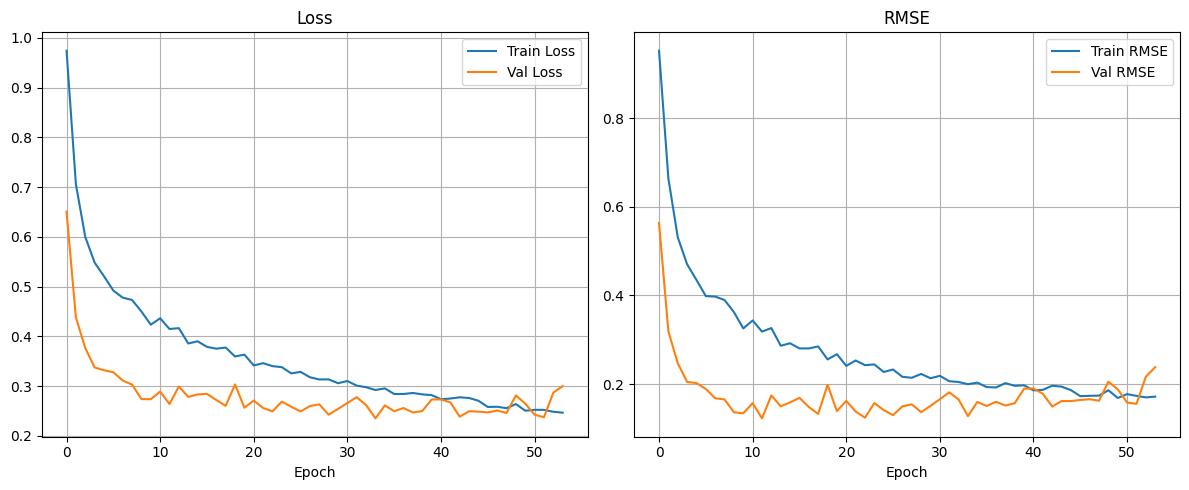

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss'); plt.xlabel('Epoch'); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history.history['root_mean_squared_error'], label='Train RMSE')
plt.plot(history.history['val_root_mean_squared_error'], label='Val RMSE')
plt.legend(); plt.title('RMSE'); plt.xlabel('Epoch'); plt.grid(True)
plt.tight_layout(); plt.show()

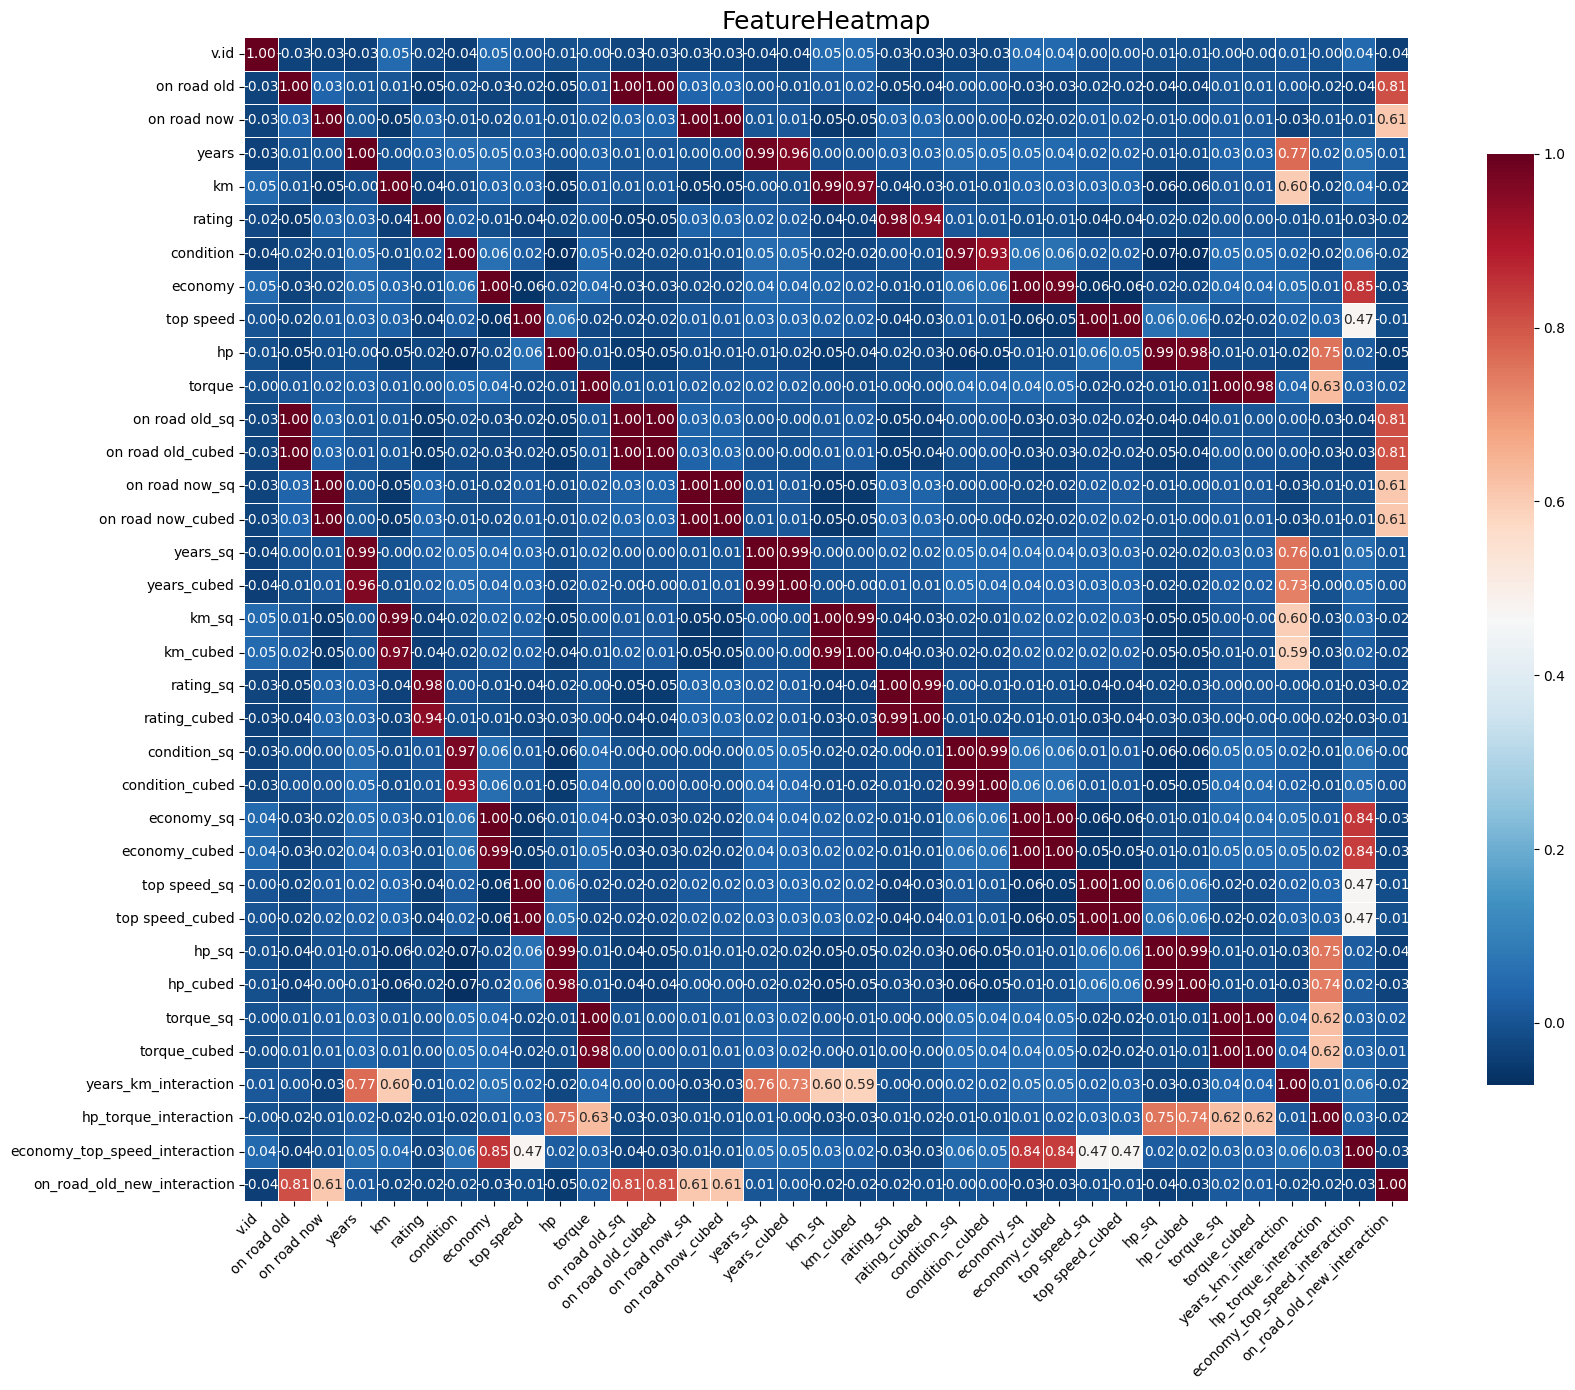

In [ ]:
plt.figure(figsize=(18, 14))
corr_matrix = pd.DataFrame(X.numpy(), columns=feature_columns).corr()

sns.heatmap(corr_matrix,
            cmap='RdBu_r',
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            square=True,
            cbar_kws={'shrink': 0.8})
plt.title("FeatureHeatmap", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


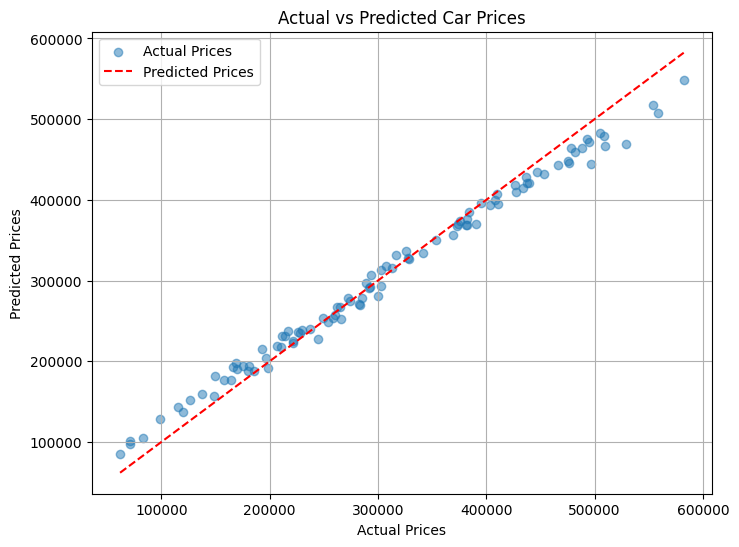

In [ ]:
import matplotlib.pyplot as plt

y_pred_norm = model.predict(X_test)
y_pred = y_pred_norm * y_std + y_mean

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.numpy().min(), y_test.numpy().max()],
         [y_test.numpy().min(), y_test.numpy().max()],
         'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Car Prices')
plt.legend(['Actual Prices', 'Predicted Prices'])
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
y_test_np = y_test.numpy().flatten()
y_pred_np = y_pred.numpy().flatten()
mae = mean_absolute_error(y_test_np, y_pred_np)
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))
r2 = r2_score(y_test_np, y_pred_np)


print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 15111.97
RMSE: 19115.59
R² Score: 0.9778
